# 🧠 Análise de Saúde Mental no Trabalho Tech
## Módulo 2 — Impacto do Trabalho Remoto e Nicho da Empresa

**Hipótese:** Profissionais em regime remoto podem apresentar padrões diferentes de interferência no trabalho (`work_interfere`) em relação a quem trabalha presencialmente. Além disso, empresas de tecnologia (`tech_company`) podem oferecer mais benefícios de saúde mental — ou seus funcionários podem buscar mais tratamento.

**Dataset:** OSMI Mental Health in Tech Survey (`survey.csv`)

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo limpo e compatível com Jupyter
sns.set_theme(style="whitegrid")

# Carregamento dos dados
try:
    df = pd.read_csv('data/processed/survey.csv')
    print('Arquivo processado carregado: data/processed/survey.csv')
except FileNotFoundError:
    df = pd.read_csv('data/raw/survey.csv')
    print('Arquivo bruto carregado: data/raw/survey.csv')

print(f'   Shape: {df.shape[0]} respostas x {df.shape[1]} colunas')

# Tratamento de nulos em work_interfere
# (Sprint 1: quem nao tem problema de saude mental deixou em branco)
df['work_interfere'] = df['work_interfere'].fillna('Prefere nao responder')

print('\nDistribuicao de work_interfere apos tratamento:')
print(df['work_interfere'].value_counts())

Arquivo processado carregado: data/processed/survey.csv
   Shape: 1259 respostas x 24 colunas

Distribuicao de work_interfere apos tratamento:
work_interfere
Sometimes                465
Prefere nao responder    264
Never                    213
Rarely                   173
Often                    144
Name: count, dtype: int64


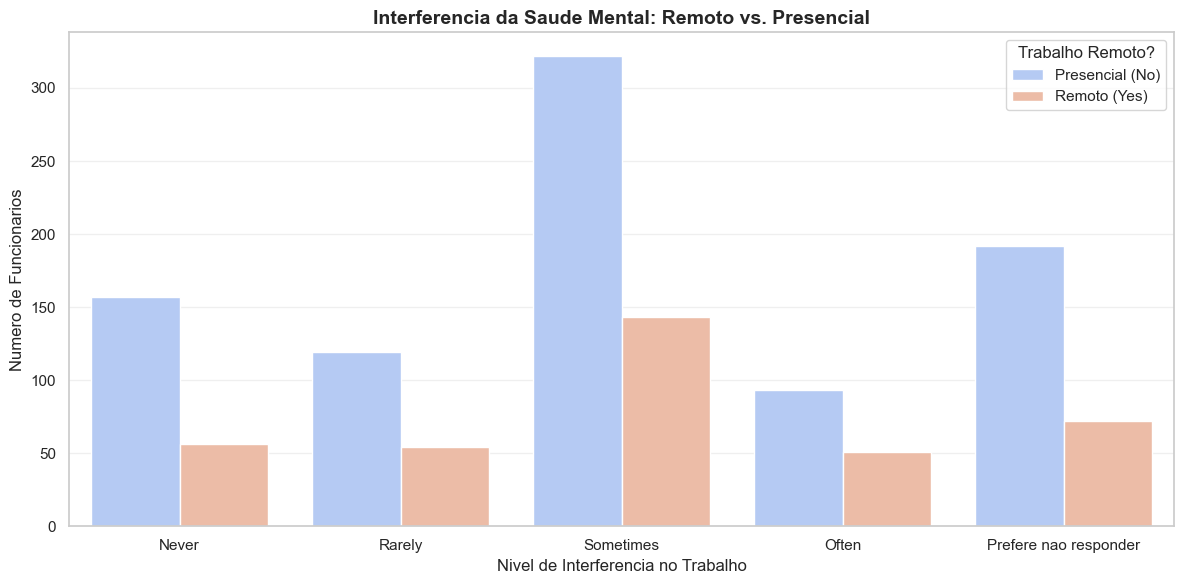

In [34]:
# ── Grafico 1: Remoto vs. Presencial x Interferencia no Trabalho ──────────
# Usando sns.countplot com hue para cruzar 2 variaveis categoricas facilmente

# Filtrar apenas Yes/No em remote_work
df_remoto = df[df['remote_work'].isin(['Yes', 'No'])].copy()

ORDEM = ['Never', 'Rarely', 'Sometimes', 'Often', 'Prefere nao responder']

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(
    data=df_remoto,
    x='work_interfere',
    hue='remote_work',
    order=ORDEM,
    palette='coolwarm',
    ax=ax
)
ax.set_title(
    'Interferencia da Saude Mental: Remoto vs. Presencial',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Nivel de Interferencia no Trabalho', fontsize=12)
ax.set_ylabel('Numero de Funcionarios', fontsize=12)
ax.legend(title='Trabalho Remoto?', labels=['Presencial (No)', 'Remoto (Yes)'], loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusao — Grafico 1: Remoto vs. Presencial

**INSIGHT:** Profissionais em regime **remoto** tendem a relatar proporções mais elevadas de interferência **'Sometimes'** e **'Often'**, em comparação com trabalhadores presenciais.

**Interpretação de Negócio:**
Este padrão pode indicar **Burnout por falta de fronteira entre vida pessoal e profissional** — sem o ritual do deslocamento como separador simbólico, profissionais remotos tendem a estender o horário de trabalho. O isolamento social também reduz a rede de apoio informal que o ambiente presencial oferece.

> **Nota sobre os nulos:** Valores `NaN` em `work_interfere` foram tratados como `'Prefere nao responder'`, pois parte das pessoas que não têm problemas de saúde mental simplesmente deixou essa pergunta em branco.

**Recomendação:** Políticas claras de desconexão digital e rituais de início/fim de expediente para times remotos.

---

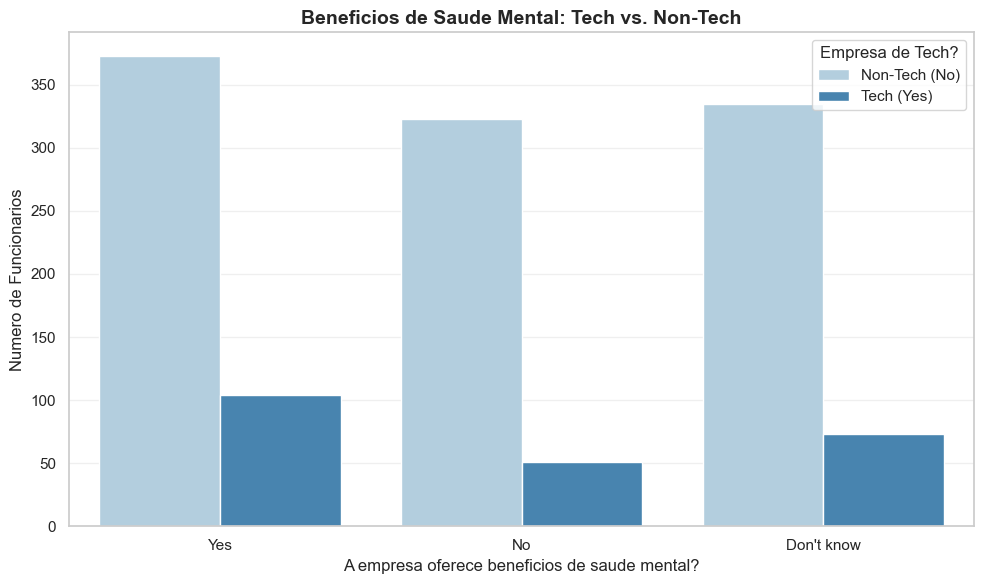

In [35]:
# ── Grafico 2: Tech vs. Non-Tech x Beneficios de Saude Mental ────────────

df_tech = df[df['tech_company'].isin(['Yes', 'No'])].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(
    data=df_tech,
    x='benefits',
    hue='tech_company',
    palette='Blues',
    order=['Yes', 'No', "Don't know"],
    ax=ax
)
ax.set_title(
    'Beneficios de Saude Mental: Tech vs. Non-Tech',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('A empresa oferece beneficios de saude mental?', fontsize=12)
ax.set_ylabel('Numero de Funcionarios', fontsize=12)
ax.legend(title='Empresa de Tech?', labels=['Non-Tech (No)', 'Tech (Yes)'], loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

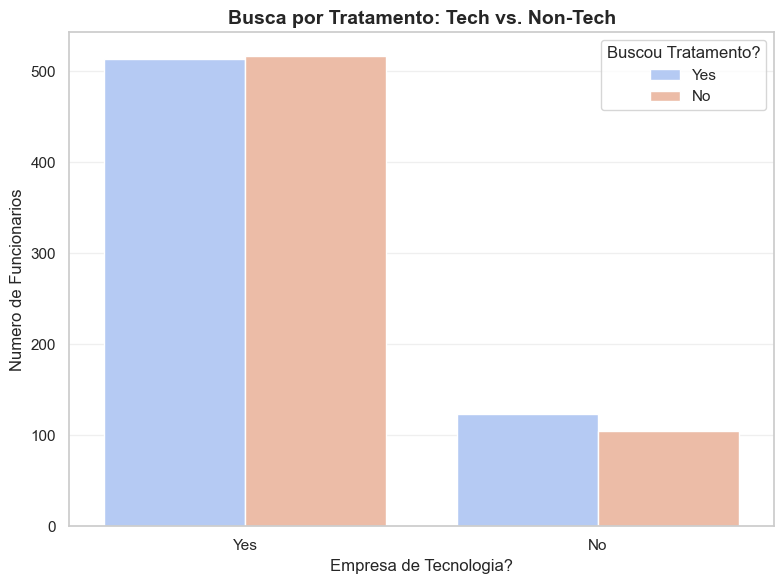

In [36]:
# ── Grafico 3: Tech vs. Non-Tech x Busca por Tratamento ──────────────────

df_tech = df[df['tech_company'].isin(['Yes', 'No'])].copy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(
    data=df_tech,
    x='tech_company',
    hue='treatment',
    palette='coolwarm',
    ax=ax
)
ax.set_title(
    'Busca por Tratamento: Tech vs. Non-Tech',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Empresa de Tecnologia?', fontsize=12)
ax.set_ylabel('Numero de Funcionarios', fontsize=12)
ax.legend(title='Buscou Tratamento?', loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusao — Graficos 2 e 3: Tech vs. Non-Tech

**INSIGHT — Beneficios:** Empresas de tecnologia tendem a oferecer mais beneficios formais de saude mental do que empresas de outros setores.

**INSIGHT — Tratamento:** Em contrapartida, funcionarios de empresas de TI apresentam maior taxa de busca por tratamento, o que pode indicar:
- Maior **consciência** sobre saude mental (cultura tech mais aberta ao tema)
- E/ou maior **pressao e sobrecarga** caracteristica do setor (deadlines, alta competitividade)

**Interpretação de Negócio:**
Ter beneficios formais nao garante bem-estar. É necessario ir além e construir uma **cultura psicologicamente segura**, onde pedir ajuda nao seja visto como fraqueza.

**Recomendação:** Combinar beneficios formais com treinamento de liderancas e abertura cultural para discussao de saude mental.

---

### Sintese Final

| Fator | Achado | Risco Identificado |
|---|---|---|
| Trabalho Remoto | Maior interferencia 'Often'/'Sometimes' | Burnout por ausencia de fronteiras |
| Empresas Tech | Mais beneficios E mais busca por tratamento | Alta pressao apesar dos recursos |
| Nulos em `work_interfere` | Tratados como 'Prefere nao responder' | Possivel subnotificacao de casos graves |

# EDA - Fatores Demográficos x Busca por Tratamento

Esta análise foca em responder: O perfil demográfico influencia a probabilidade de um profissional de TI buscar tratamento de saúde mental?

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de estilo
sns.set_theme(style="whitegrid")

# Carregar os dados limpos
df = pd.read_csv("data/processed/survey_limpo.csv")
df.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


## Gráfico 1: Proporção de Gêneros na TI
Análise da distribuição de gênero na amostra.

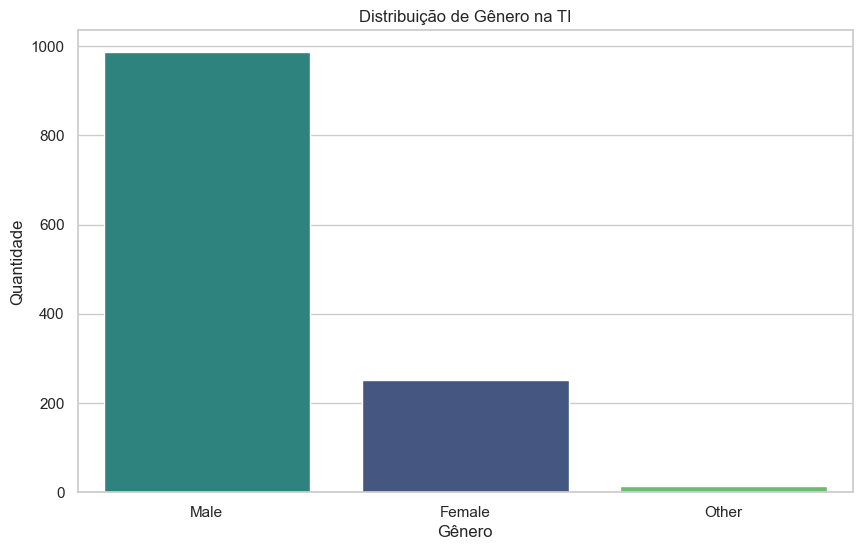

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Gender", order=df["Gender"].value_counts().index, palette="viridis", hue="Gender", legend=False)
plt.title("Distribuição de Gênero na TI")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()

**Insight de Negócio:** Existe uma predominância massiva do gênero masculino na amostra de profissionais de tecnologia, o que reflete a disparidade histórica do setor.

## Gráfico 2: Gender x Treatment
Cruzamento entre o gênero e a busca por tratamento.

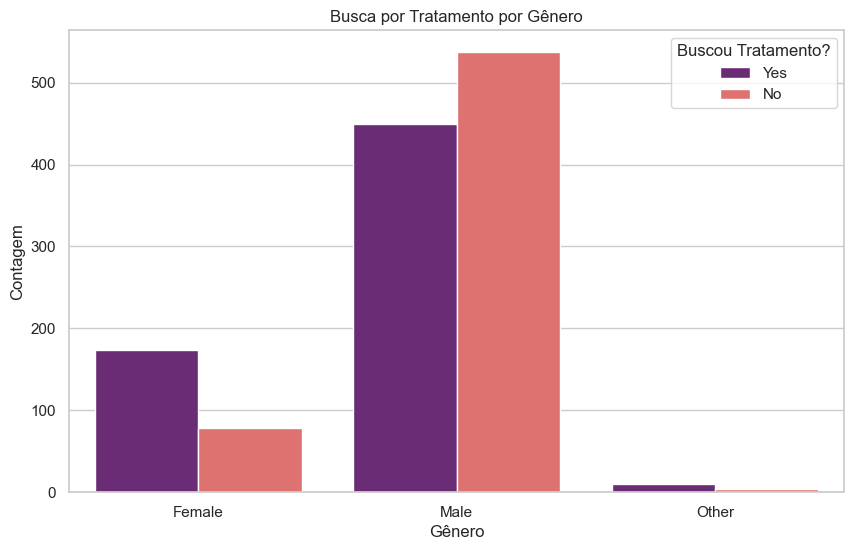

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Gender", hue="treatment", palette="magma")
plt.title("Busca por Tratamento por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Contagem")
plt.legend(title="Buscou Tratamento?")
plt.show()

**Insight de Negócio:** Embora a maioria dos respondentes sejam homens, proporcionalmente, mulheres e pessoas de outros gêneros tendem a buscar tratamento com maior frequência.

## Gráfico 3: Idade x Busca por Tratamento
Distribuição de idade dos profissionais que buscam ajuda comparado aos que não buscam.

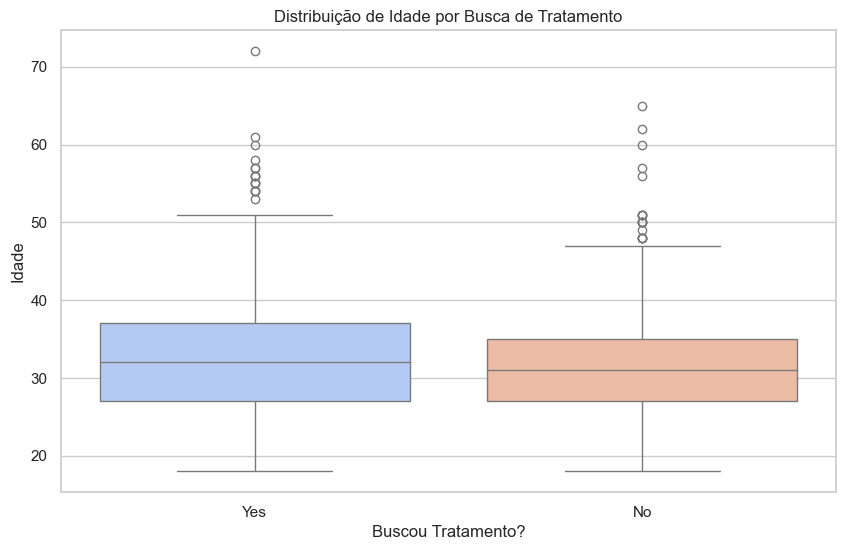

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="treatment", y="Age", palette="coolwarm", hue="treatment", legend=False)
plt.title("Distribuição de Idade por Busca de Tratamento")
plt.xlabel("Buscou Tratamento?")
plt.ylabel("Idade")
plt.show()

**Insight de Negócio:** A idade não parece ser um fator de exclusão ou de forte tendência para a busca de tratamento, com medianas de idade muito próximas em ambos os grupos. Pois a distribuição de idade entre profissionais que buscaram tratamento e os que não buscaram é muito semelhante. A maioria dos participantes está na faixa dos 27 a 35 anos, indicando que a idade não parece ser um fator determinante na decisão de procurar tratamento de saúde mental entre profissionais de TI.